In [1]:
import pathlib
import astropy.units as u
import xarray
import matplotlib.pyplot as plt
import numpy as np
import dask.array
import distributed
import scipy.stats

from astropy.visualization import ImageNormalize, AsymmetricPercentileInterval, LogStretch

In [2]:
data_dir = pathlib.Path('../data/moxsi_gsfc_calibration_images/')

In [3]:
def fitting_function(X, a, b, c, d, e, f):
    t_det0, t_adc, exposure = X
    return a + b * exposure * np.exp(t_det0 / c) + d * t_det0 + e * t_det0**2 + f * t_adc

In [4]:
ds = xarray.open_zarr(data_dir / 'images.zarr')

# Pedestal Fit Parameter Correlations

$y = a + b t_{exp} \exp{T_{det0} / c} + d T_{det0} + e T_{det0}^2 + f T_{ADC}$

In [5]:
da_coeffs = xarray.open_dataarray(data_dir / 'fit_coefficients.nc')

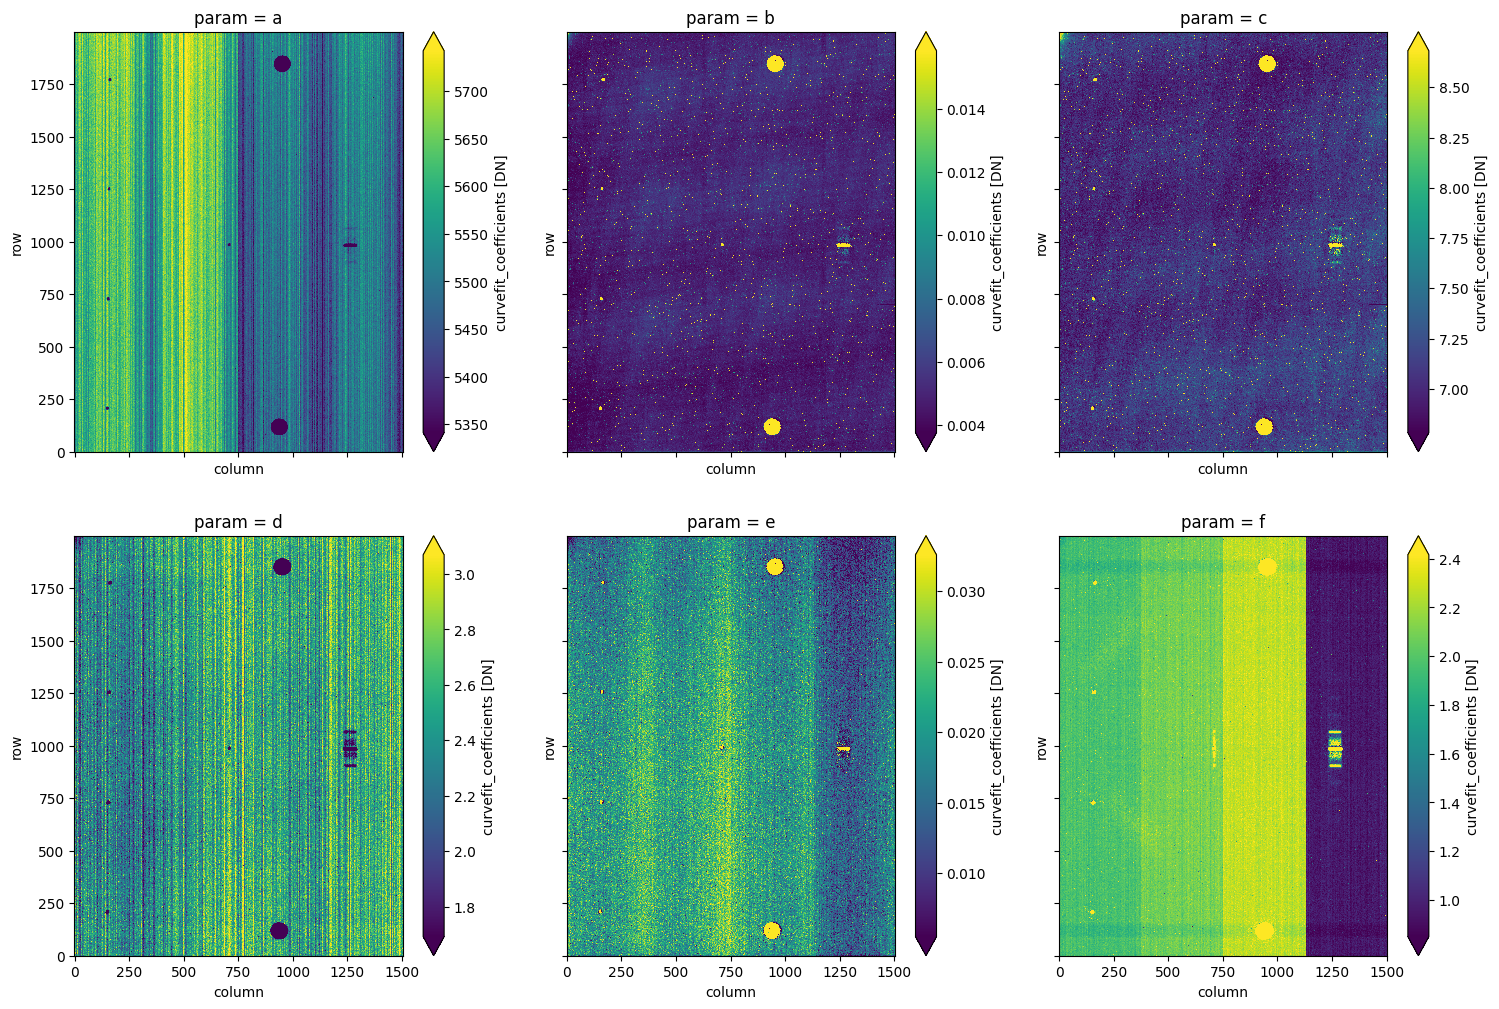

In [6]:
size = 6 
fig,axes = plt.subplots(2,3,figsize=(size*3,size*2),sharex=True,sharey=True)
for i,ax in enumerate(axes.flatten()):
    vmin, vmax = AsymmetricPercentileInterval(1,99).get_limits(da_coeffs[...,i].data)
    da_coeffs[...,i].plot.imshow(ax=ax, vmin=max(0,vmin), vmax=vmax)

In [7]:
data_coeffs_flat = np.array([da_coeffs.sel(param=p).data.flatten() for p in da_coeffs.param.data])
data_coeffs_flat = data_coeffs_flat[:,np.isfinite(data_coeffs_flat).all(axis=0)]
data_coeffs_flat = {p: d for p,d in zip(da_coeffs.param.data, data_coeffs_flat)}


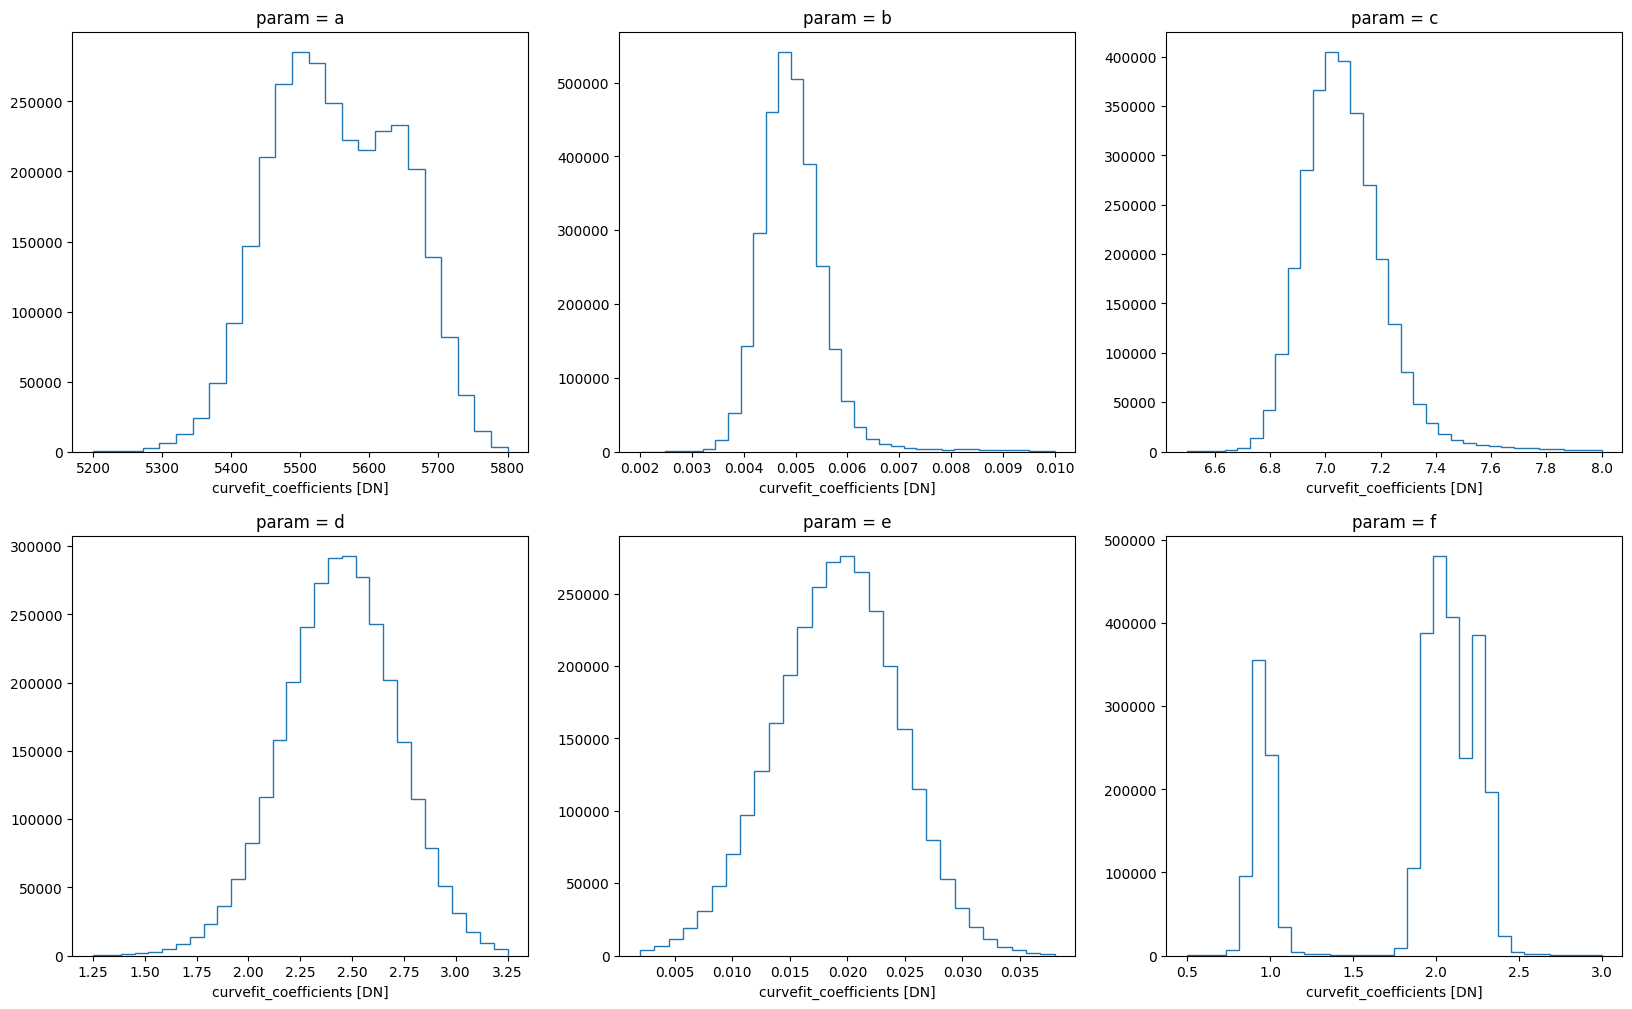

In [25]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False)
bin_edges = {}
range_dict = {'a': [5200,5800], 'b': [0.002, 0.01], 'c': [6.5,8.0], 'd': [1.25,3.25], 'e': [0.002,0.038], 'f': [0.5,3.0]}
for i,ax in enumerate(axes.flatten()):
    if (range := range_dict.get(str(da_coeffs.param[i].data))) is None:
        range = AsymmetricPercentileInterval(0.5,99.5).get_limits(da_coeffs[...,i].data)
    _,be,_ = da_coeffs[...,i].plot.hist(ax=ax, bins='doane', range=range, histtype='step', log=False)
    bin_edges[str(da_coeffs.param[i].data)] = be
    #vmin, vmax = AsymmetricPercentileInterval(0.5,99).get_limits(da_coeffs[...,i].data)
    #_,be,_ = da_coeffs[...,i].plot.hist(ax=ax, bins='scott', range=(vmin,vmax), histtype='step', log=False)

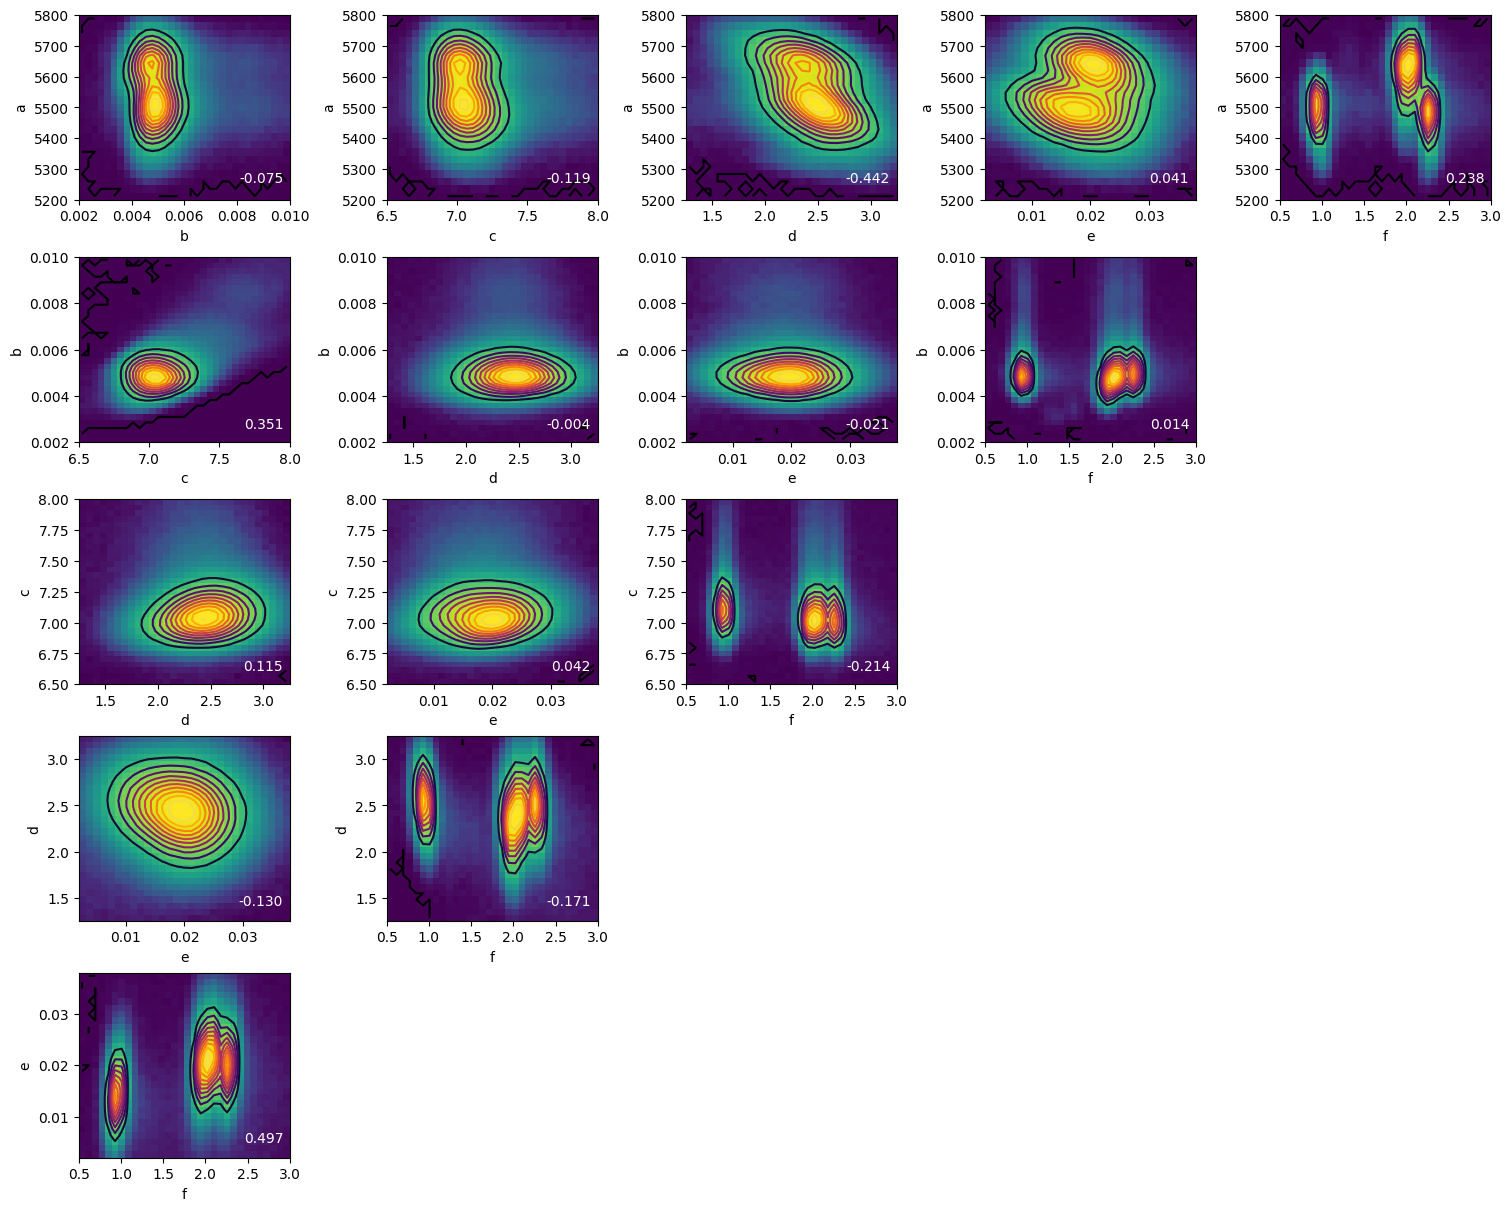

In [26]:
fig = plt.figure(figsize=(15,12), layout='constrained')
for j,q in enumerate(da_coeffs.param.data[:-1]):
    for i,p in enumerate(da_coeffs.param.data[j+1:]):
        ax = fig.add_subplot(5,5,i+1+5*j)
        #ax.plot(data_coeffs_flat[p], data_coeffs_flat[q], ls='', marker='.', alpha=0.25)
        counts,_,_,_ = ax.hist2d(data_coeffs_flat[p],
                  data_coeffs_flat[q],
                  bins=[bin_edges[p], bin_edges[q]],
                  norm=ImageNormalize(stretch=LogStretch()))
        Y,X = np.meshgrid((bin_edges[q][:-1] + bin_edges[q][1:])/2,
                         (bin_edges[p][:-1] + bin_edges[p][1:])/2)
        ax.contour(
            X,Y,
            counts,
            levels=10,
            cmap='inferno',
        )
        xp = data_coeffs_flat[p]
        yq = data_coeffs_flat[q]
        idx = np.logical_and(xp>=bin_edges[p][0], xp<=bin_edges[p][-1]) * np.logical_and(yq>=bin_edges[q][0], yq<=bin_edges[q][-1])
        res = scipy.stats.pearsonr(xp[idx], yq[idx])
        #if xlim := ax_limits.get(p):
        #    ax.set_xlim(xlim)
        #if ylim := ax_limits.get(q):
        #    ax.set_ylim(ylim)
        ax.set_xlabel(p)
        ax.set_ylabel(q)
        #ax.label_outer()
        ax.text(bin_edges[p][-2], bin_edges[q][2], f'{res.statistic:.3f}', color='w', va='bottom', ha='right')

## Refitting: Fixed $f$

Make an estimate of the mean value of $f$ in each segment

In [27]:
# I came up with these numbers by looking at a map of $f$ and segmenting it across columns manually
f_divisions = [
    [0,375],
    [375,750],
    [750,1125],
    [1125, 1504],
]

In [28]:
import astropy.modeling.fitting
from astropy.modeling.models import Gaussian1D

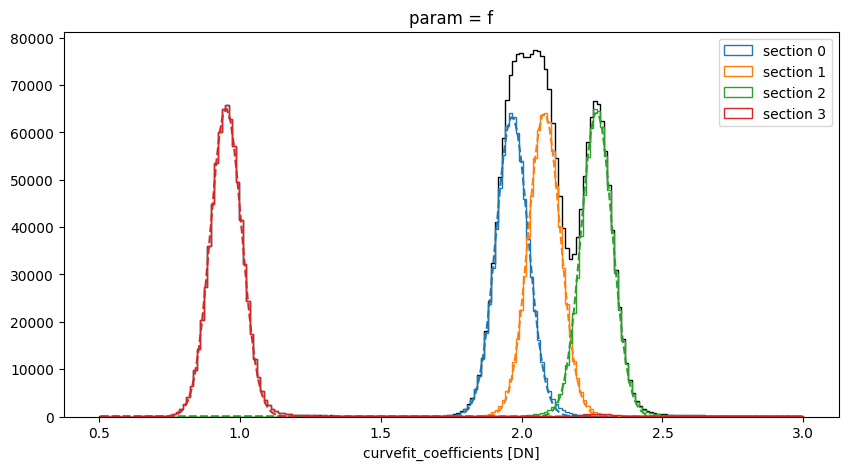

In [29]:
f_fixed_estimate = []
plt.figure(figsize=(10,5))
_,bins,_ = da_coeffs.sel(param='f').plot.hist(bins='scott', range=(0.5,3),histtype='step',color='k');
for i,fd in enumerate(f_divisions):
    y,xedge,patch = da_coeffs.sel(param='f')[:,fd[0]:fd[1]].plot.hist(bins=bins,histtype='step',label=f'section {i}')
    xmid = (xedge[1:]+xedge[:-1])/2
    fitter = astropy.modeling.fitting.TRFLSQFitter()
    ginit = Gaussian1D(amplitude=y.max(), mean=xmid[y.argmax()], stddev=0.5)
    gfit = fitter(ginit, xmid, y)
    plt.plot(xmid, gfit(xmid),color=patch[0].get_edgecolor(), ls='--')
    f_fixed_estimate.append(gfit.mean)
plt.legend()

In [31]:
f_fixed_estimate

[Parameter('mean', value=1.9662495342645396),
 Parameter('mean', value=2.08083032721758),
 Parameter('mean', value=2.2667223450191125),
 Parameter('mean', value=0.9512635133522603)]

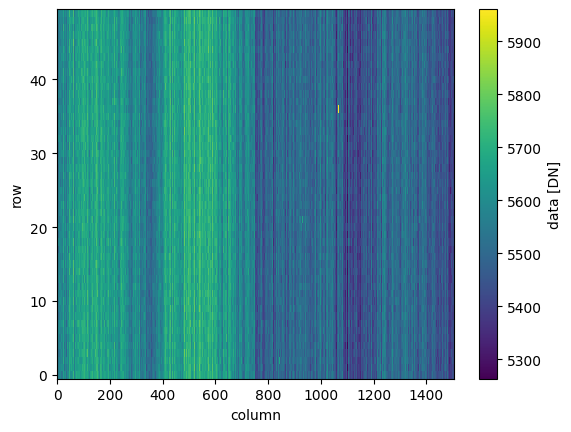

In [74]:
ds['data'][:,250:300,:].median(dim='sample').plot()

In [22]:
client = distributed.Client(address='tcp://127.0.0.1:36085')

In [49]:
da_coeffs_fixed_f = []
for fd, fe in zip(f_divisions, f_fixed_estimate):
    print(fd)
    

    def fitting_function_fixed_f(X, a, b, c, d, e):
        t_det0, t_adc, exposure = X
        return a + b * exposure * np.exp(t_det0 / c) + d * t_det0 + e * t_det0**2 + fe * t_adc


    da_fit = ds['data'][:, 250:300, fd[0]:fd[-1]].curvefit(
        (ds.temperature_detector_0, ds.temperature_adc, ds.exposure_time),
        fitting_function_fixed_f,
        reduce_dims=['sample'],
        errors='ignore',
    )
    da_coeffs_fixed_f.append(da_fit.curvefit_coefficients.compute())

[0, 375]
[375, 750]
[750, 1125]
[1125, 1504]


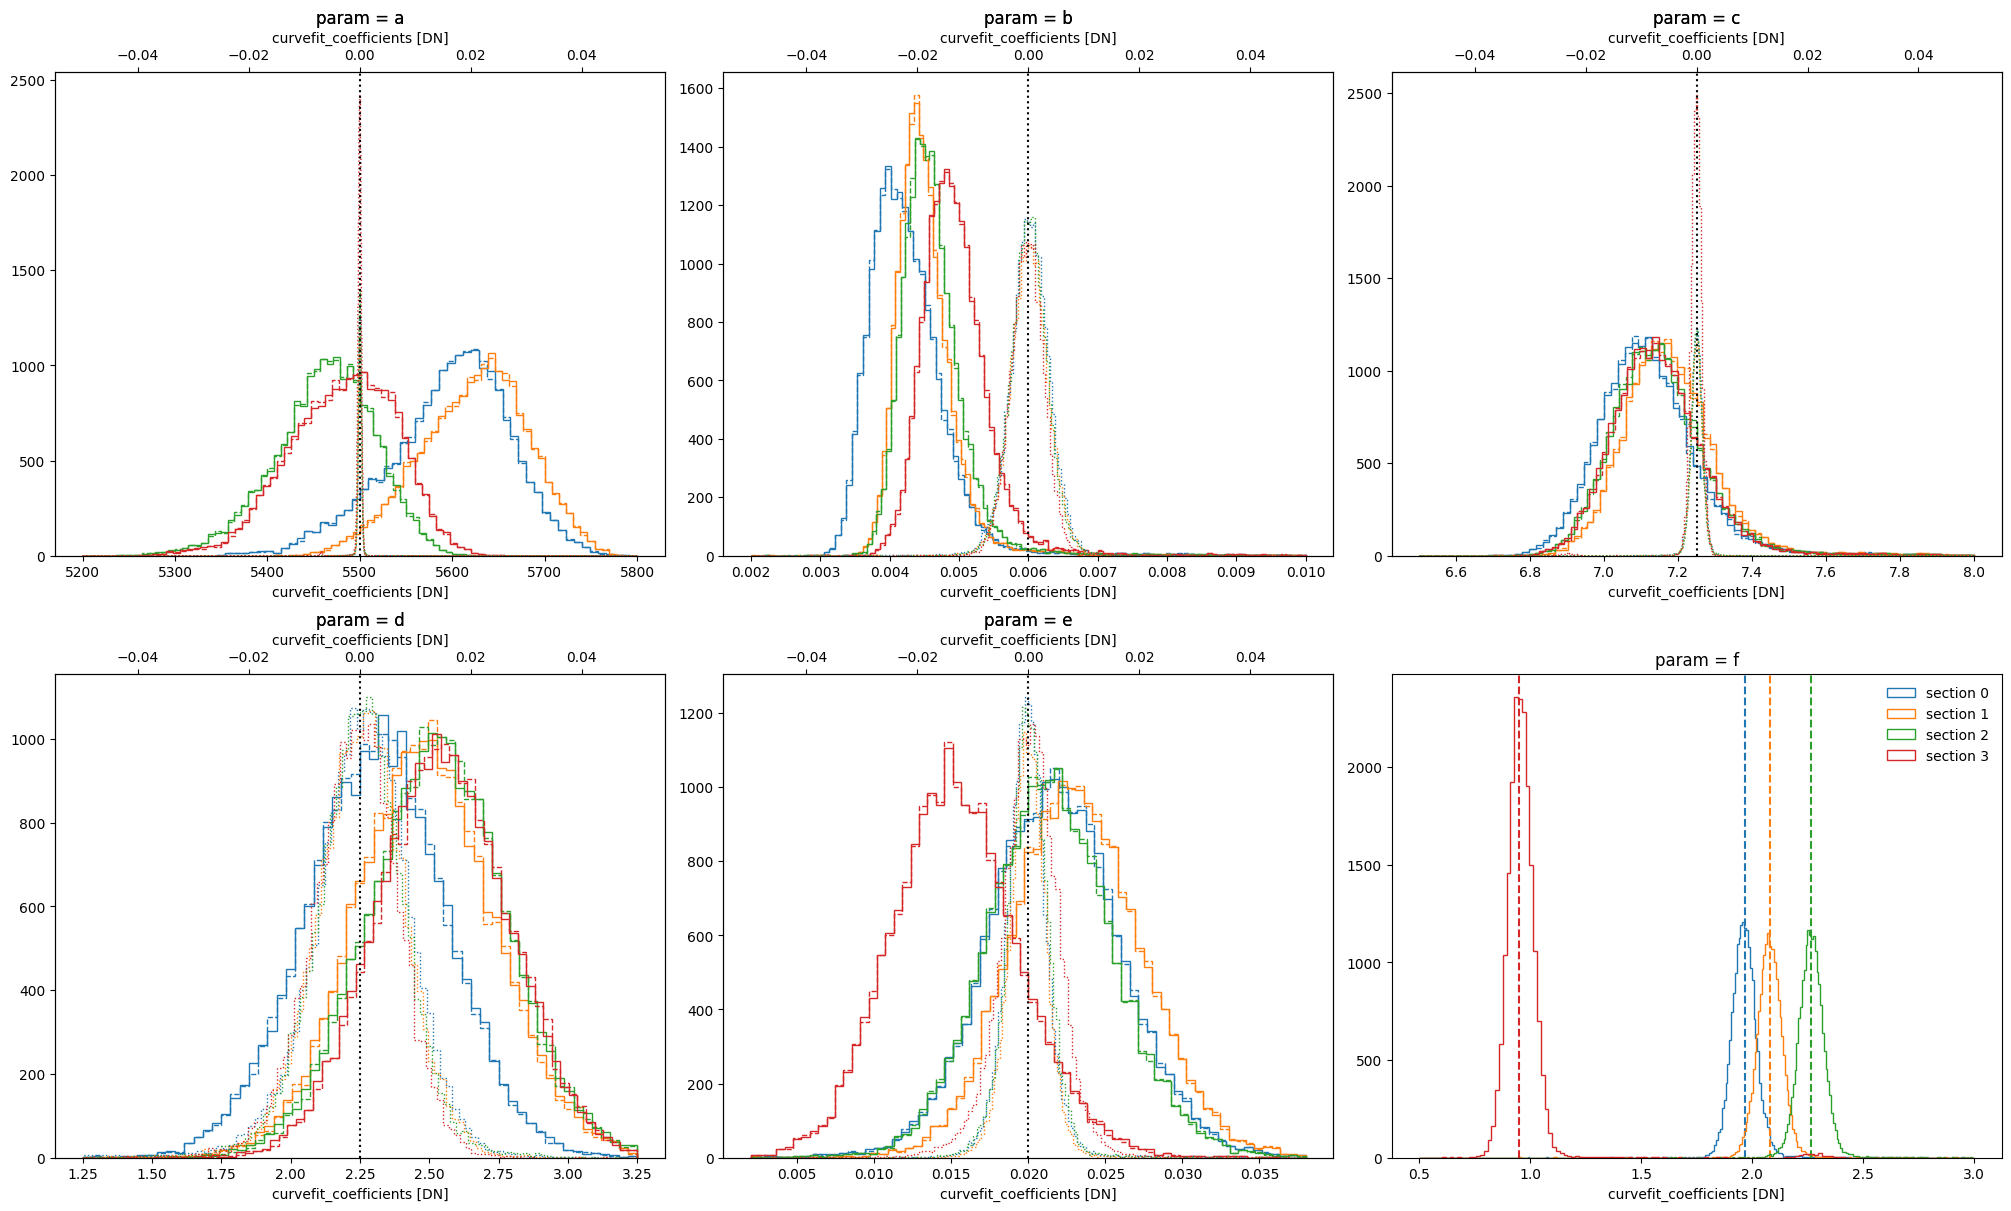

In [66]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False, layout='constrained')
for i,ax in enumerate(axes.flatten()):
    if i < 5:
        ax2 = ax.twiny()
    range = range_dict.get(str(da_coeffs.param[i].data))
    for j,fd in enumerate(f_divisions):
        param_true = da_coeffs[250:300,fd[0]:fd[-1],i]
        _,be,patch = param_true.plot.hist(ax=ax, bins='scott', histtype='step', range=range, log=False, label=f'section {j}')
        if i<5:
            param_fixed_f = da_coeffs_fixed_f[j].isel(param=i)
            param_fixed_f.plot.hist(ax=ax, bins=be, histtype='step', log=False, color=patch[0].get_edgecolor(), ls='--')
            diff = (param_true - param_fixed_f) / param_true
            diff.plot.hist(ax=ax2, color=patch[0].get_edgecolor(), ls=':', histtype='step', log=False, bins='scott', range=(-0.05,0.05))
        if i==5:
            ax.axvline(x=f_fixed_estimate[j].value, color=patch[0].get_edgecolor(), ls='--')
    if i == 5:
        ax.legend(loc=1, frameon=False)
    else:
        #ax2.set_xlim(-0.01,0.01)
        ax2.axvline(x=0, color='k', ls=':')

## Refitting: Subzero Temperatures

In [104]:
idx = np.where(np.logical_and(ds.temperature_detector_0 < 0, ds.temperature_detector_1 < 0))
ds_subzero = ds.isel(sample=idx[0])

In [80]:
da_fit = ds_subzero['data'][:,250:300,:].curvefit(
    (ds_subzero.temperature_detector_0, ds_subzero.temperature_adc, ds_subzero.exposure_time),
    fitting_function,
    reduce_dims=['sample'],
    errors='ignore',
)

In [81]:
da_coeffs_subzero = da_fit.curvefit_coefficients.compute()

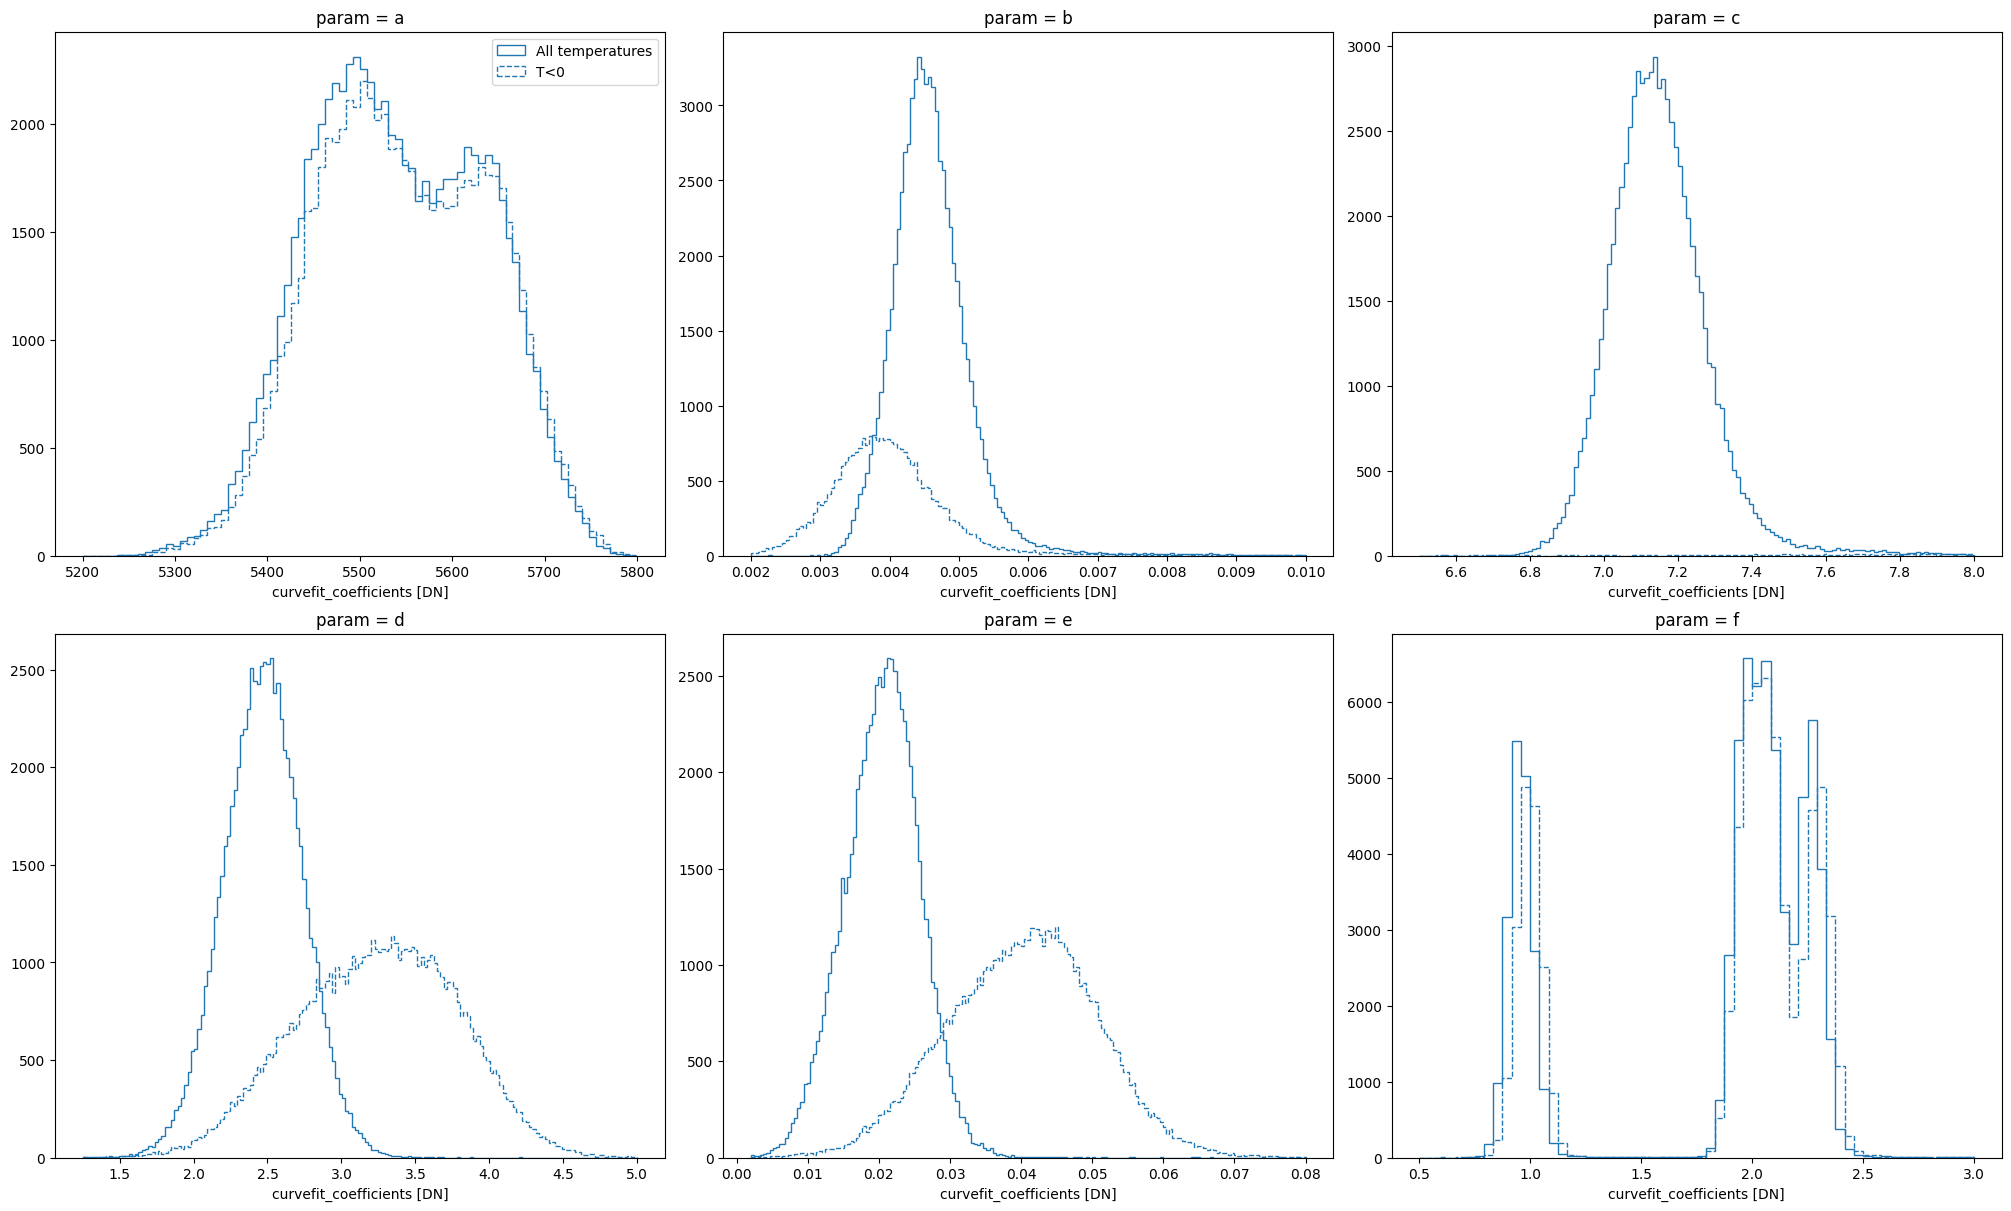

In [97]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False, layout='constrained')
range_dict = {'a': [5200,5800], 'b': [0.002, 0.01], 'c': [6.5,8.0], 'd': [1.25,5], 'e': [0.002,0.08], 'f': [0.5,3.0]}
for i,ax in enumerate(axes.flatten()):
    #ax2 = ax.twiny()
    range = range_dict.get(str(da_coeffs.param[i].data))
    param_true = da_coeffs[250:300,:,i]
    _,be,patch = param_true.plot.hist(ax=ax, bins='scott', histtype='step', range=range, log=False, label=f'All temperatures')
    param_subzero= da_coeffs_subzero.isel(param=i)
    param_subzero.plot.hist(ax=ax, histtype='step', log=False, color=patch[0].get_edgecolor(), ls='--', bins=be, label='T<0')
    diff = (param_true - param_subzero) / param_true
    #diff.plot.hist(ax=ax2, color=patch[0].get_edgecolor(), ls=':', histtype='step', log=False, bins='scott',)
    #ax2.axvline(x=0, color='k', ls='--')
    if i == 0:
        ax.legend()

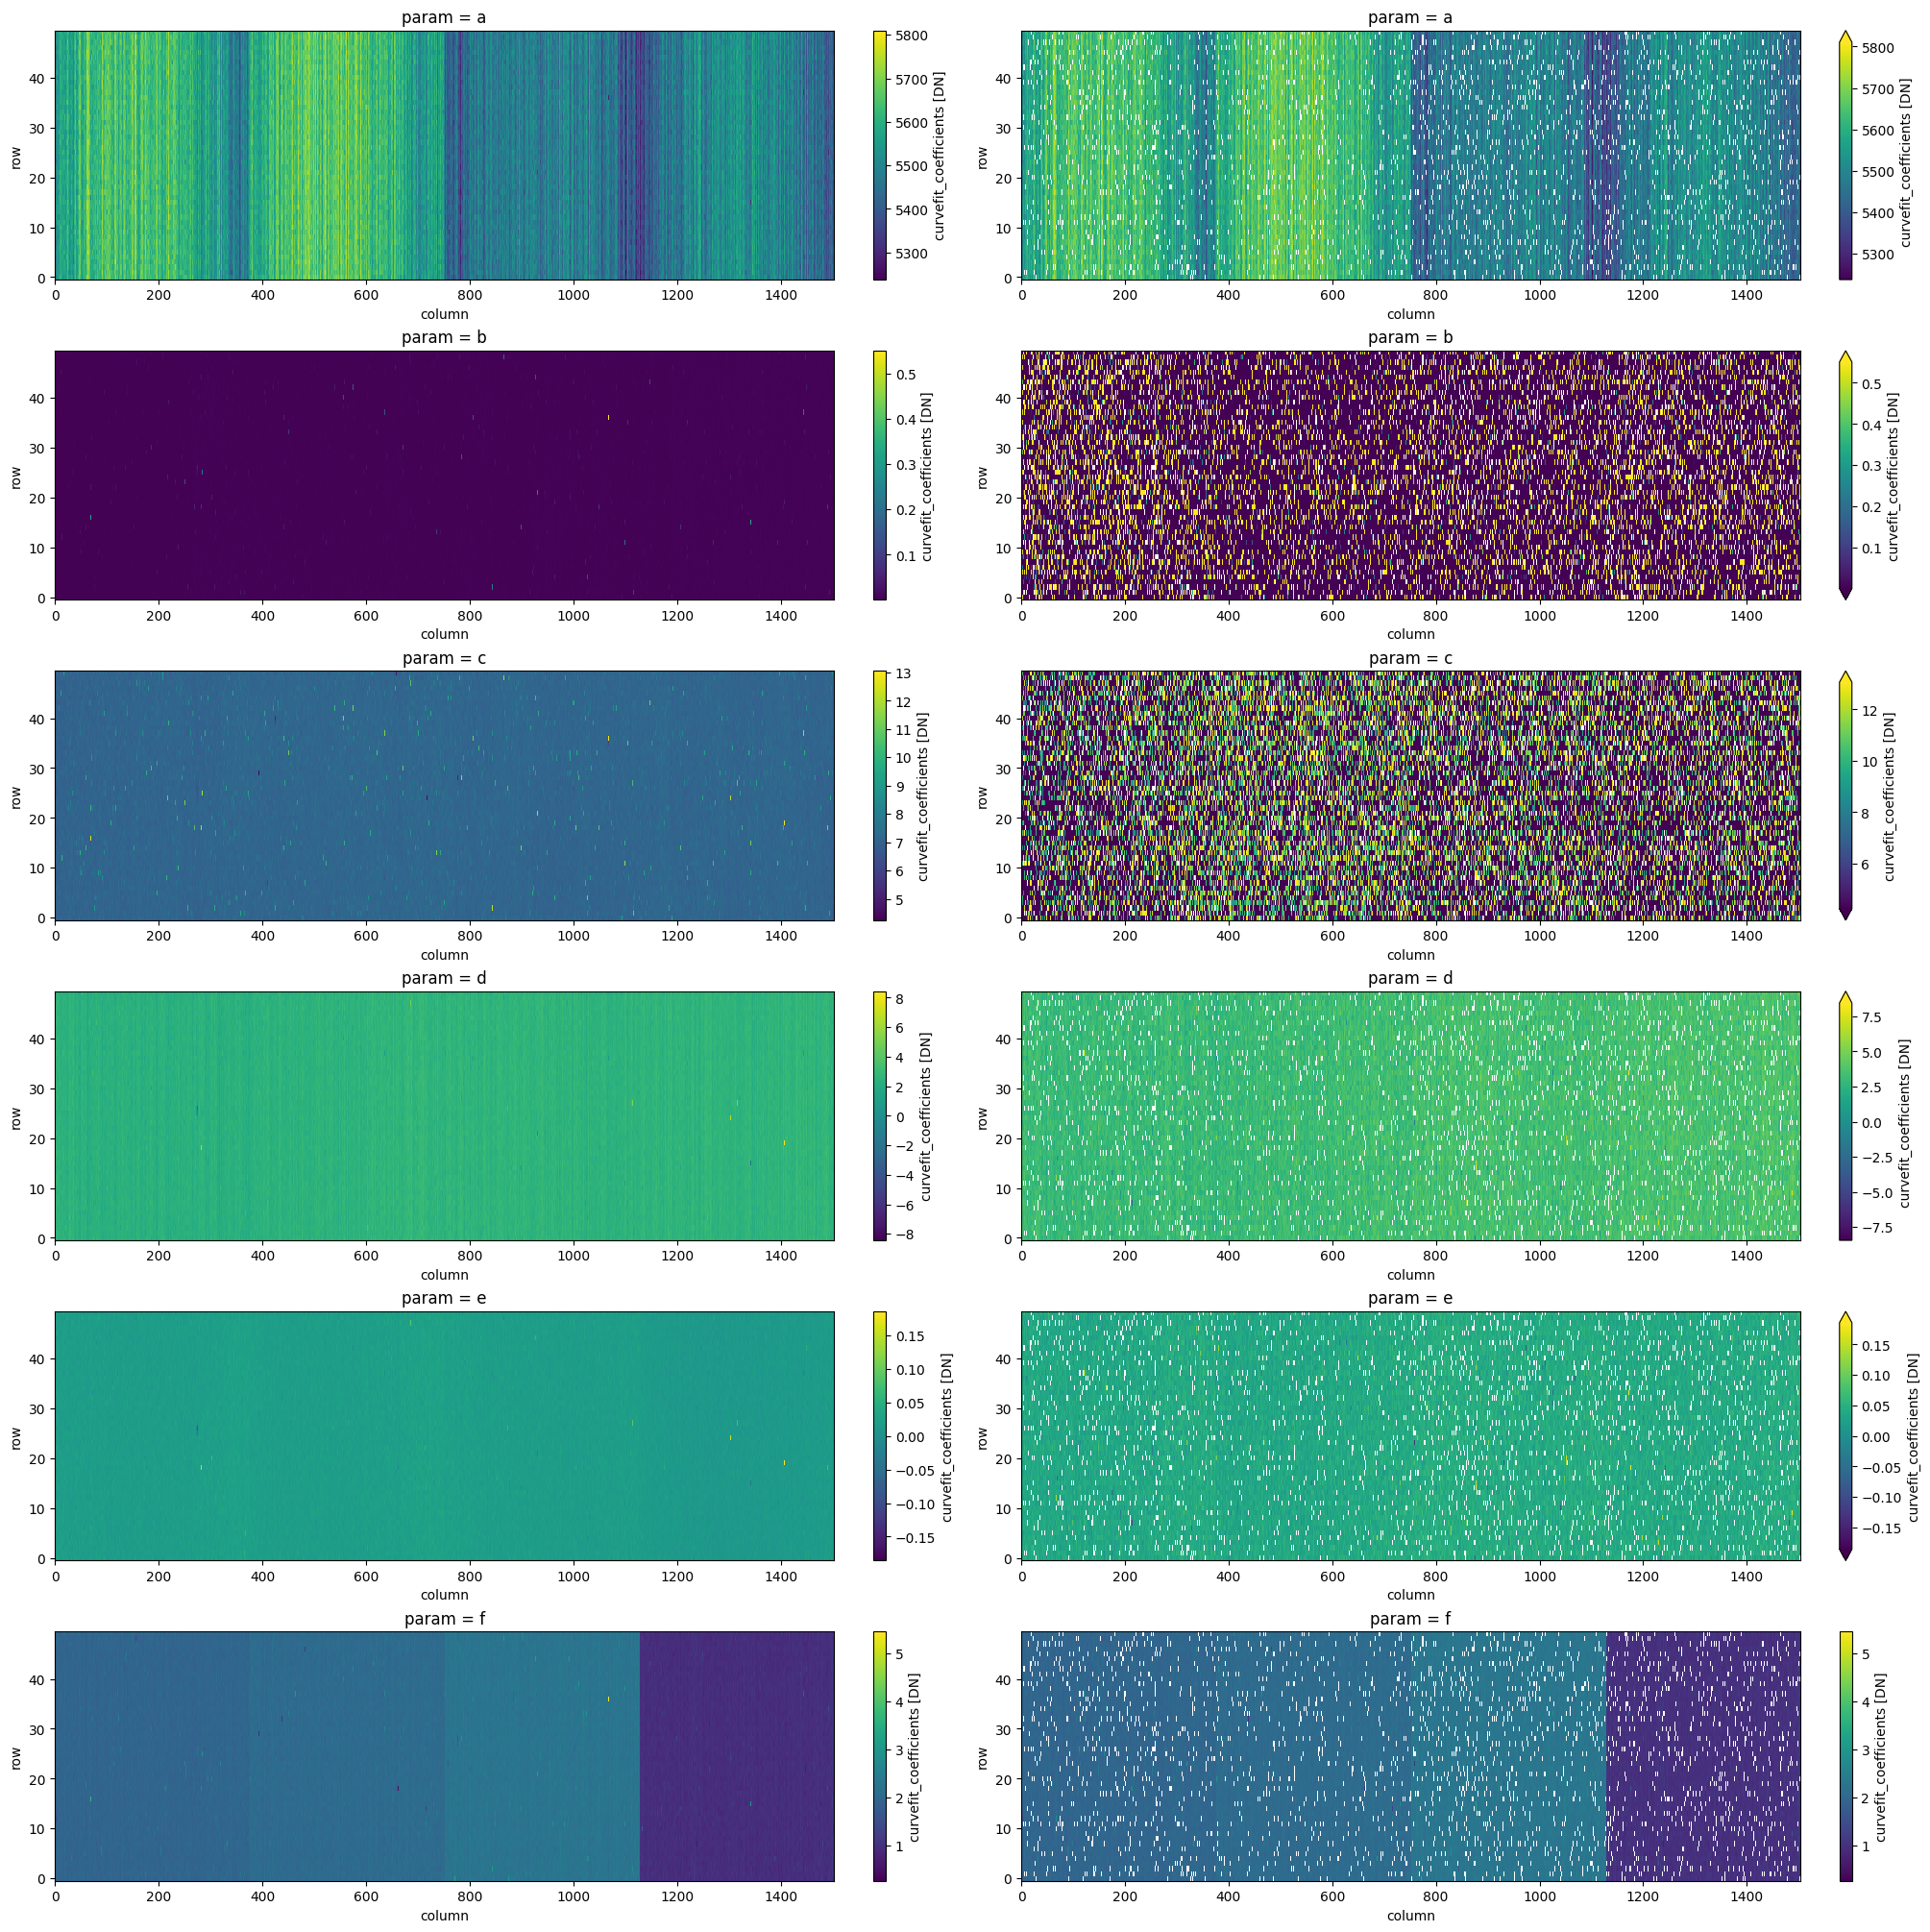

In [112]:
fig = plt.figure(figsize=(20,20),layout='constrained')
for i,param in enumerate(da_coeffs.param):
    ax = fig.add_subplot(6,2,2*i+1)
    im = da_coeffs.sel(param=param)[250:300,:].plot.imshow(ax=ax,cmap='viridis')
    ax = fig.add_subplot(6,2,2*(i+1))
    da_coeffs_subzero.sel(param=param).plot.imshow(ax=ax, norm=im.norm,cmap='viridis')